In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# **Обзор данных**

In [3]:
data = pd.read_parquet("../data/processed/move_ru_clean.parquet")
data.head()

,url,listing_id,title,deal_type,object_type,price,rooms,area_total,area_kitchen,area_living,...,seller_type,photo_count,image_urls,is_studio,has_balcony,has_elevator,has_parking,has_renovation,description,parse_errors
0,https://move.ru/objects/moskva_pereulok_simono...,9293574125,"3-комнатной квартиры, 87.3 м²",sale,apartment,55000000.0,3.0,87.3,13.3,49.3,...,owner,58.0,['https://static-i6.move.ru/images/items/10002...,0.0,0.0,0.0,0.0,1.0,вп - 2694. легкая альтернатива. 1 взрослый соб...,[]
1,https://move.ru/objects/moskva_proezd_kutuzovs...,9287887608,"2-комнатная квартира, 63.8 м²",sale,apartment,67500185.0,2.0,63.8,20.7,25.0,...,NaN,14.0,['https://static-i6.move.ru/images/items/10009...,0.0,0.0,1.0,1.0,0.0,премиальная жизнь на берегу москвы-реки почему...,[]
2,https://move.ru/objects/moskva_prospekt_40_let...,9287820819,"1-комнатную квартиру, 27.1 м²",sale,apartment,16500000.0,1.0,27.1,8.0,12.0,...,owner,38.0,['https://static-i6.move.ru/images/items/10009...,0.0,0.0,1.0,1.0,1.0,собственник. дом клубного плана. продам уютную...,[]
3,https://move.ru/objects/moskva_prospekt_60-let...,9293539455,"1-комнатной квартиры, 34 м²",sale,apartment,21200000.0,1.0,34.0,8.0,24.0,...,owner,46.0,['https://static-i6.move.ru/images/items/10002...,0.0,1.0,0.0,0.0,1.0,вп - 2695. свободная продажа. 1 взрослый собст...,[]
4,https://move.ru/objects/moskva_prospekt_kutuzo...,9284926509,"3-комнатную квартиру, 112 м²",sale,apartment,142000000.0,3.0,112.0,32.0,80.0,...,developer,28.0,['https://static-i6.move.ru/images/items/10009...,0.0,0.0,0.0,1.0,NaN,жилой комплекс бадаевский 112 м2 клубный дом. ...,[]


In [11]:
print(f"{data.shape}\n")
display(data.info())
display(data.describe(include="all").T)

(14534, 31)

<class 'pandas.DataFrame'>
RangeIndex: 14534 entries, 0 to 14533
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              14534 non-null  str    
 1   listing_id       14534 non-null  str    
 2   title            14534 non-null  str    
 3   deal_type        14534 non-null  str    
 4   object_type      14534 non-null  str    
 5   price            14534 non-null  float64
 6   rooms            14534 non-null  float64
 7   area_total       14534 non-null  float64
 8   area_kitchen     12563 non-null  float64
 9   area_living      14229 non-null  float64
 10  price_per_m2     14534 non-null  float64
 11  address          12958 non-null  str    
 12  okrug            14298 non-null  str    
 13  district         14534 non-null  str    
 14  metro            14534 non-null  str    
 15  metro_time_min   14533 non-null  float64
 16  floor            14534 non-null  float64
 17  total_floo

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
url,14534,14534,https://move.ru/objects/moskva_pereulok_simono...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listing_id,14534,14534,9293574125,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,14534,6969,"студию от застройщика, 28.02 м²",43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deal_type,14534,1,sale,14534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
object_type,14534,1,apartment,14534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,14534.0,NaN,NaN,NaN,27820357.191482,35351245.640549,4117000.0,11791463.0,18974048.0,29315875.0,496822000.0
rooms,14534.0,NaN,NaN,NaN,1.687973,0.866748,1.0,1.0,1.0,2.0,7.0
area_total,14534.0,NaN,NaN,NaN,54.425106,27.236144,13.5,36.1525,47.6,65.5,388.2
area_kitchen,12563.0,NaN,NaN,NaN,17.75372,7.784378,2.2,13.08,16.9,20.6,88.5
area_living,14229.0,NaN,NaN,NaN,23.61819,14.671246,6.4,13.5,19.9,29.26,388.2


In [8]:
duplicates = data["listing_id"].duplicated().sum()
print("Количество дубликатов:", duplicates)

duplicates_example = data[data["listing_id"].duplicated(keep=False)].head()
duplicates_example

Количество дубликатов: 0


,url,listing_id,title,deal_type,object_type,price,rooms,area_total,area_kitchen,area_living,...,seller_type,photo_count,image_urls,is_studio,has_balcony,has_elevator,has_parking,has_renovation,description,parse_errors


# **Анализ пропусков**

,missing_count,missing_percent
house_type,14169,97.49
year_built,12911,88.83
has_renovation,8977,61.77
completion_year,4525,31.13
area_kitchen,1971,13.56
seller_type,1614,11.10
address,1576,10.84
area_living,305,2.10
okrug,236,1.62
metro_time_min,1,0.01


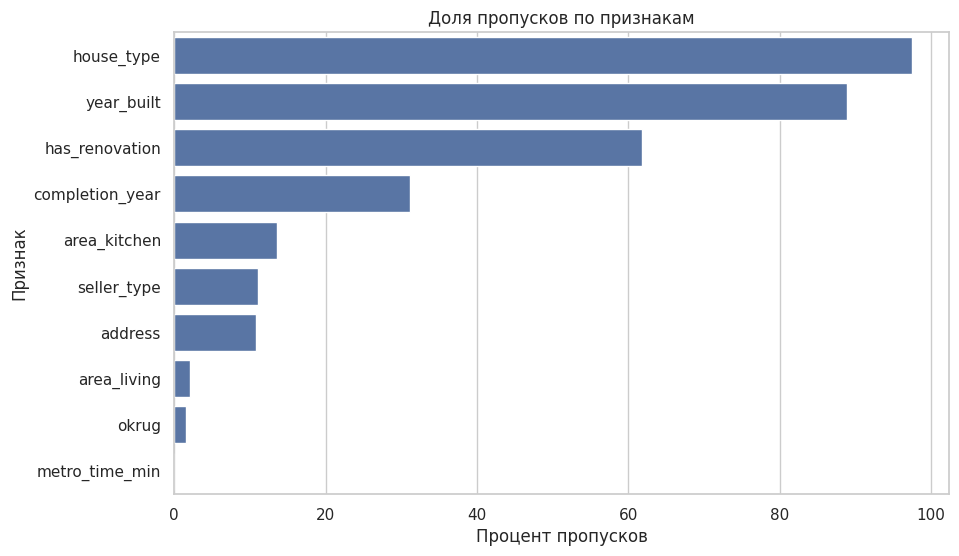

In [19]:
missing = data.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

missing_percent = (missing / len(data) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

display(missing_df)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_df["missing_percent"], y=missing_df.index)
plt.title("Доля пропусков по признакам")
plt.xlabel("Процент пропусков")
plt.ylabel("Признак")
plt.show()

### **Вывод по пропускам:**

В данных присутствуют пропуски, но они распределены неравномерно по признакам.

Наиболее проблемные признаки:
  - `house_type` (~97%) и `year_built` (~89%) — практически полностью отсутствуют
  - `has_renovation` (~62%) и `completion_year` (~31%) — значительная доля пропусков


Умеренные пропуски:
  - `area_kitchen`, `seller_type`, `address` (~10–13%)


Почти полные признаки:
  - `area_living`, `okrug`, `metro_time_min` — пропуски незначительны

Признаки с большим количеством пропусков заполняются (например, "unknown" или -1) либо могут быть исключены из модели при необходимости. Признаки с малым количеством пропусков можно безопасно использовать

# **Анализ таргета price_per_m2**

In [23]:
target = "price_per_m2"

display(data[target].describe())

count    1.453400e+04
mean     4.628676e+05
std      2.776192e+05
min      6.232877e+04
25%      2.723000e+05
50%      4.137500e+05
75%      5.617000e+05
max      3.444449e+06
Name: price_per_m2, dtype: float64

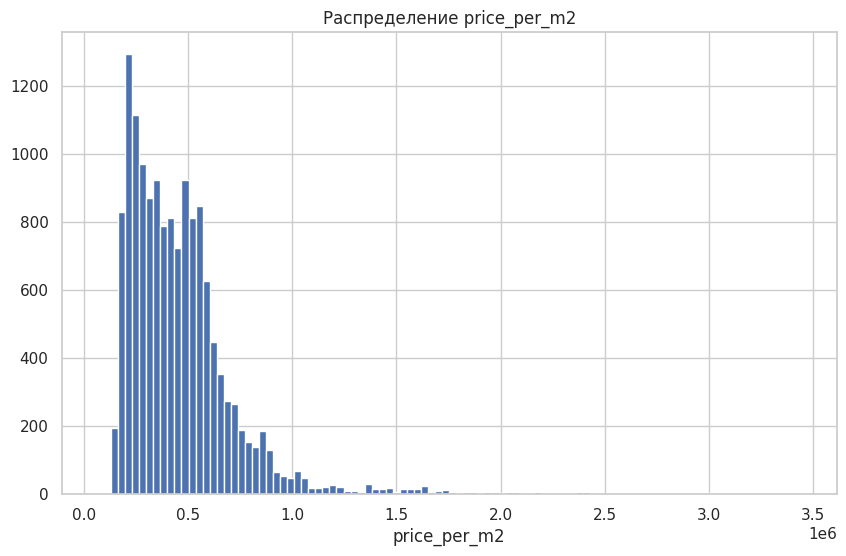

In [26]:
plt.figure(figsize=(10, 6))
plt.hist(data[target], bins=100)
plt.title("Распределение price_per_m2")
plt.xlabel("price_per_m2")
plt.show()

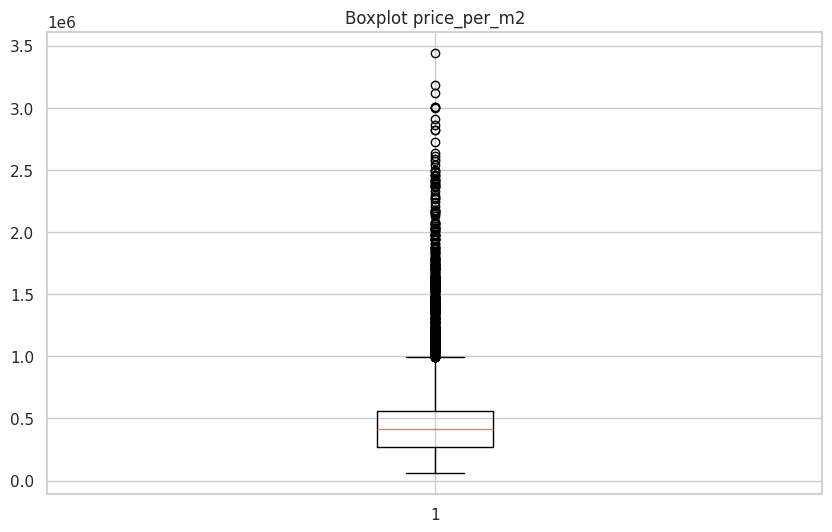

In [27]:
plt.figure(figsize=(10, 6))
plt.boxplot(x=data[target])
plt.title("Boxplot price_per_m2")
plt.show()

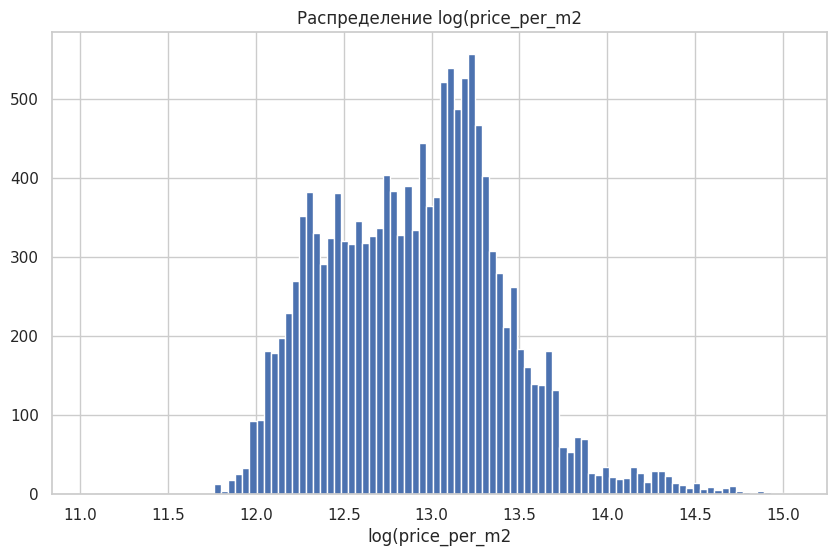

In [28]:
data["log_price_per_m2"] = np.log1p(data["price_per_m2"])

plt.figure(figsize=(10, 6))
plt.hist(data["log_price_per_m2"], bins=100)
plt.title("Распределение log(price_per_m2")
plt.xlabel("log(price_per_m2")
plt.show()

### **Вывод по таргету (price_per_m2):**

- Распределение `price_per_m2` сильно скошено вправо (right-skewed)
- Присутствует длинный хвост — есть дорогие выбросы (элитная недвижимость)
- Основная масса значений сосредоточена в диапазоне ~200k–600k руб/м²

По boxplot:
- наблюдается большое количество выбросов
- медиана значительно ниже максимальных значений

Логарифмирование:
- `log(price_per_m2)` делает распределение более симметричным и близким к нормальному
- это может быть полезно для моделей


Таргет имеет выбросы и асимметрию, модель должна быть устойчива к выбросам (например, CatBoost), лог-трансформация рассмотрена как потенциальное улучшение

# **Анализ числовых признаков**

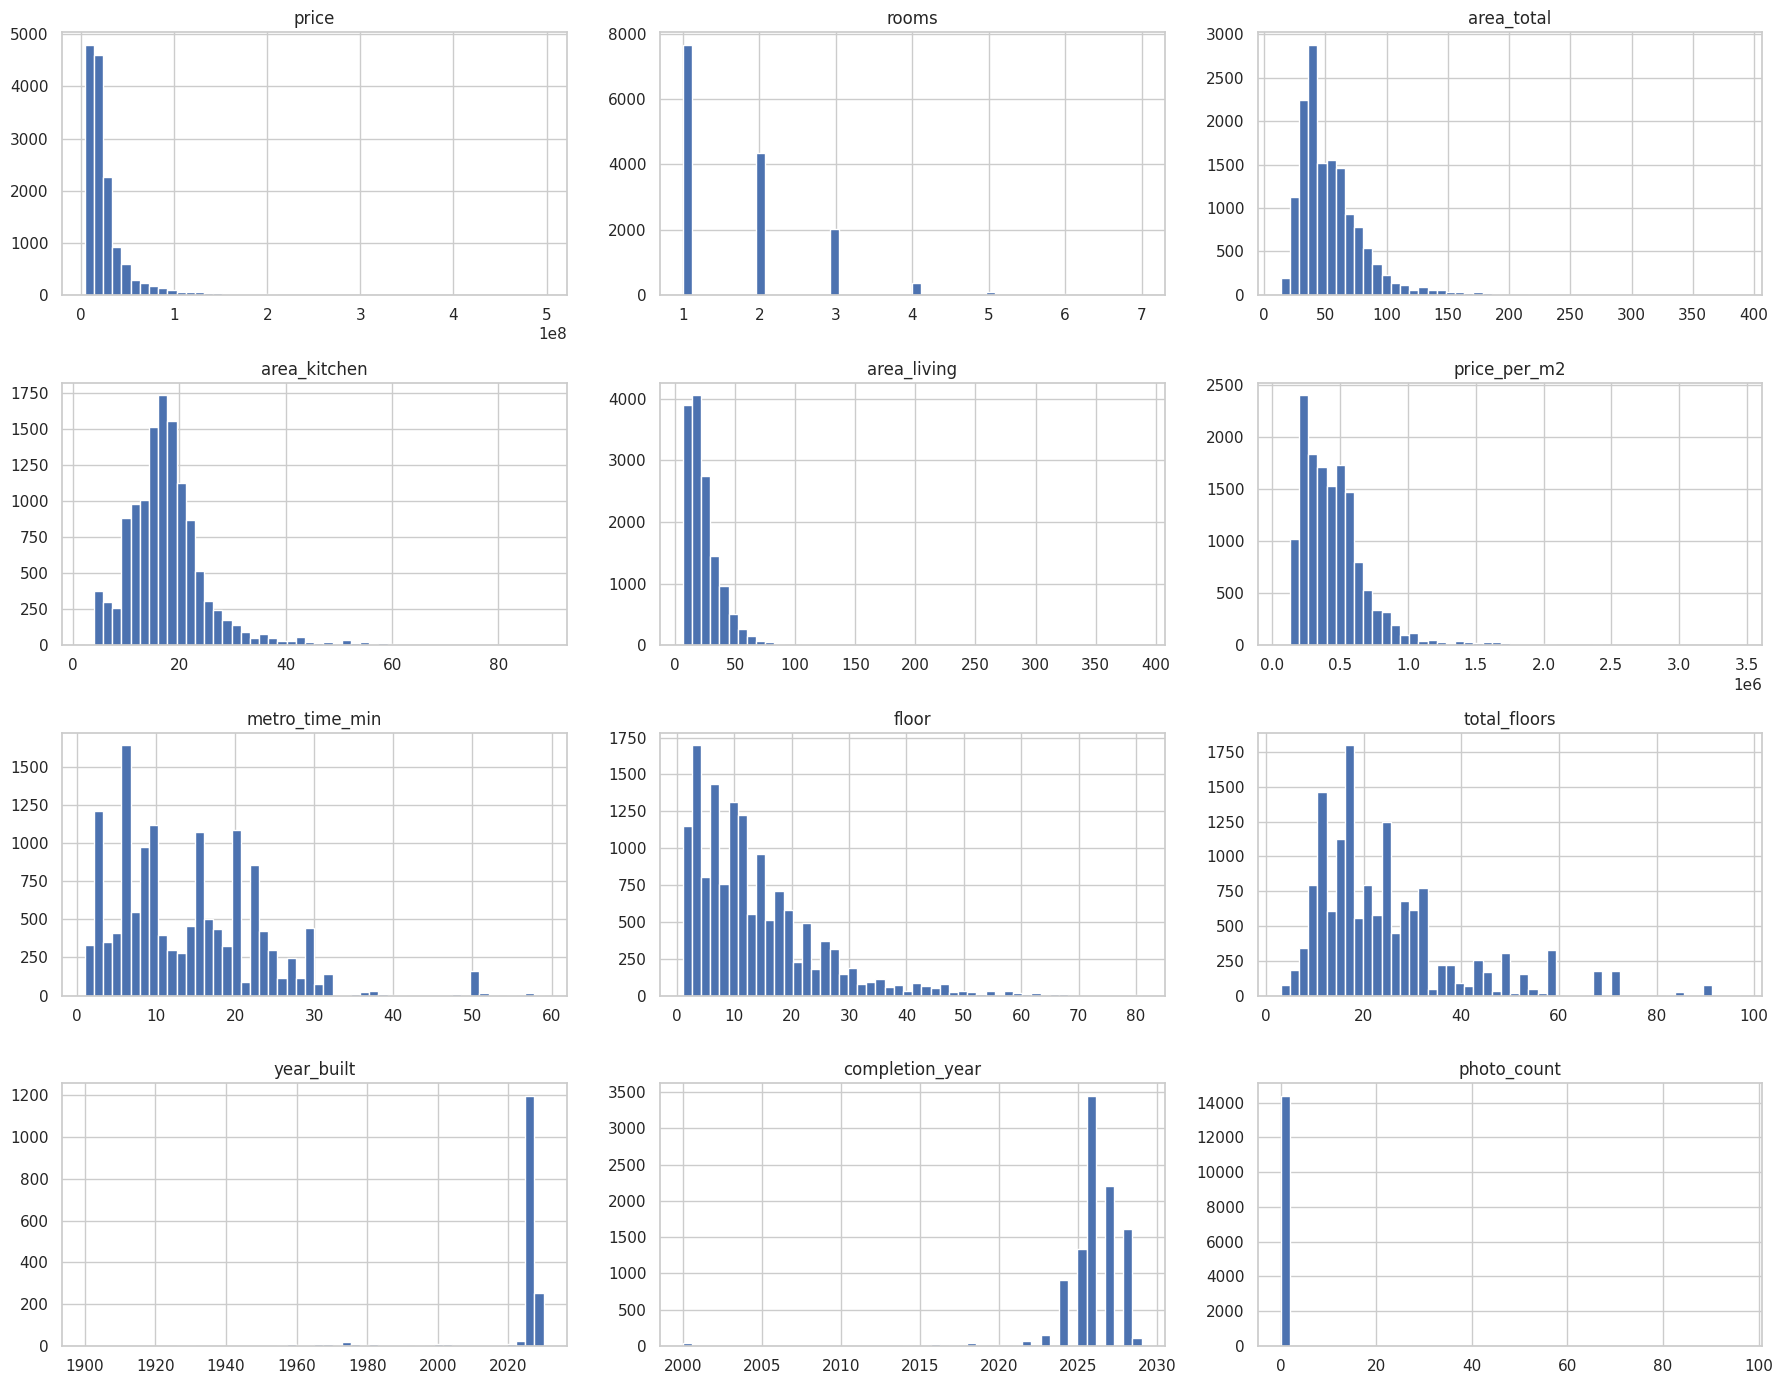

In [37]:
num_cols = [
    "price", "rooms", "area_total", "area_kitchen", "area_living",
    "price_per_m2", "metro_time_min", "floor", "total_floors",
    "year_built", "completion_year", "photo_count"
]



data[num_cols].hist(bins=50, figsize=(18, 14))
plt.tight_layout()
plt.show()

### **Вывод по числовым признакам:**

- Большинство числовых признаков имеют скошенное распределение (особенно `price`, `area_total`, `area_living`)
- Наблюдаются длинные хвосты → присутствуют выбросы (крупные квартиры, элитная недвижимость)
- Признаки, связанные с площадью (`area_total`, `area_living`, `area_kitchen`), имеют логичное распределение и потенциально сильно влияют на цену
- `rooms` — дискретный признак, основная масса объектов: 1–3 комнаты
- `metro_time_min` показывает широкий разброс, что важно для цены
- `floor` и `total_floors` имеют разумное распределение, но есть выбросы (высокие этажи)
- `year_built` и `completion_year` смещены к современным значениям → преобладает новая застройка
- `photo_count` имеет сильную концентрацию у низких значений


Данные реалистичны и отражают структуру рынка недвижимости, присутствуют выбросы → модель должна быть устойчива к ним, признаки площади, района и удаленности от метро — ключевые для предсказания цены

# **Корреляции числовых признаков**

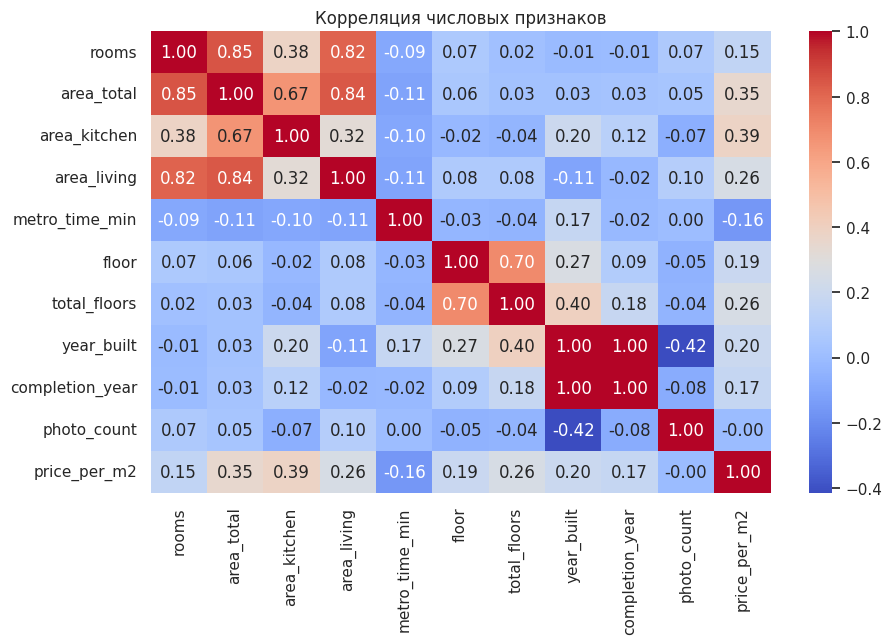

In [39]:
corr_cols = [
    "rooms", "area_total", "area_kitchen", "area_living",
    "metro_time_min", "floor", "total_floors", "year_built",
    "completion_year", "photo_count", "price_per_m2"
]

corr = data[corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляция числовых признаков")
plt.show()

### **Вывод по корреляциям числовых признаков:**

- Сильная корреляция между признаками площади:
  - `area_total`, `area_living`, `rooms` → дублирующая информация (мультиколлинеарность)
- `price_per_m2` умеренно коррелирует с:
  - `area_kitchen` (~0.39)
  - `area_total` (~0.35)
  - `total_floors`, `area_living` (~0.25–0.26)
- Отрицательная корреляция:
  - `metro_time_min` (~ -0.16) → чем дальше от метро, тем ниже цена
- Признаки этажности (`floor`, `total_floors`) умеренно связаны (~0.70 между собой)
- `year_built` и `completion_year` практически дублируют друг друга (~1.0)


Ключевые факторы цены: площадь, удаленность от метро, характеристики дома, есть мультиколлинеарность → не критично для CatBoost, но важно понимать, часть признаков дублирует информацию (например, `year_built` и `completion_year`)

# **Анализ категориальных признаков**

In [44]:
cat_cols = [
    "okrug", "district", "metro", "house_type", "seller_type"
]

for col in cat_cols:
    print(f"\n{col}")
    print(data[col].value_counts(dropna=False).head(10))


okrug
okrug
ЦАО     3863
ЗАО     2256
ЮВАО    2022
ЮАО     1472
СВАО    1025
ВАО      945
САО      886
СЗАО     801
ЮЗАО     655
НМАО     369
Name: count, dtype: int64

district
district
Дорогомилово               1101
Выхино-Жулебино             950
Обновлено сегодня в         781
Орехово-Борисово Южное      774
СП Сосенское                664
Ховрино                     649
Северное Медведково         638
ул Багрицкого Обновлено     444
ул Верейская Обновлено      443
Гольяново                   413
Name: count, dtype: int64

metro
metro
Пятницкое шоссе    1096
Котельники         1051
Давыдково           905
Молодежная          728
Медведково          638
Кожуховская         589
Водный стадион      478
Домодедовская       470
Щелковская          450
Новопеределкино     414
Name: count, dtype: int64

house_type
house_type
NaN                    14169
монолитный               244
кирпичный                 65
панельный                 45
блочный                    6
сталинский         

### **Вывод по категориальным признакам:**

- `deal_type` и `object_type` неинформативны (одно значение → не влияют на модель)
- `okrug`, `district`, `metro` — ключевые географические признаки:
  - имеют большое количество уникальных значений
  - напрямую влияют на цену недвижимости
- `district` и `metro` имеют высокий кардиналити → важно корректно обрабатывать (CatBoost подходит)
- `house_type` практически полностью отсутствует (~97%) → малополезный признак
- `seller_type` сильно несбалансирован:
  - большинство объявлений — от застройщика (developer)
- `address` имеет много уникальных значений → сложно использовать напрямую
- `description` — текстовый признак, может быть использован отдельно (например, через NLP)
- `image_urls` — признак наличия изображений, сами изображения не используются на baseline


Наиболее важные категориальные признаки: `district`, `metro`, `okrug`, часть признаков либо неинформативна, либо имеет слишком много пропусков, CatBoost позволяет эффективно работать с категориальными признаками без сложного кодирования

# **Влияние категорий на price_per_m2**

### **По округам**

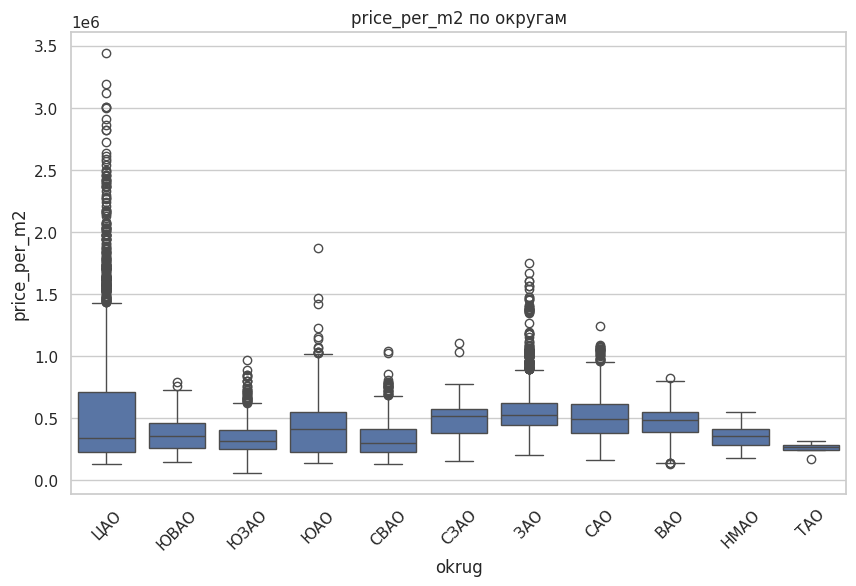

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="okrug", y="price_per_m2")
plt.xticks(rotation=45)
plt.title("price_per_m2 по округам")
plt.show()

### **По районам**

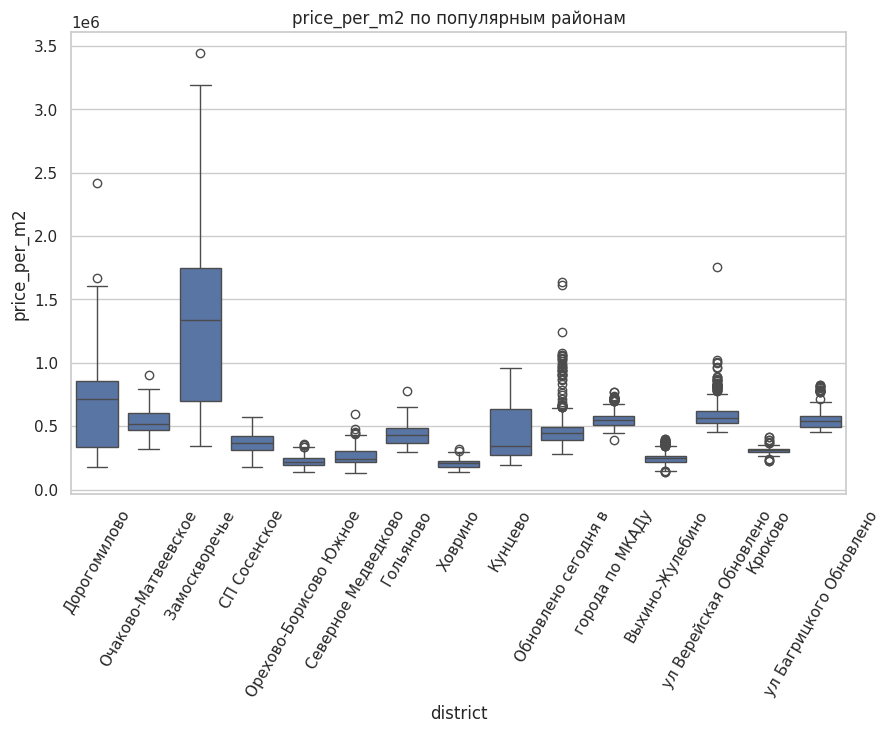

In [53]:
top_districts = data["district"].value_counts().head(15).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=data[data["district"].isin(top_districts)],
            x="district",
            y="price_per_m2"
)
plt.xticks(rotation=60)
plt.title("price_per_m2 по популярным районам")
plt.show()


## Вывод по влиянию категориальных признаков на price_per_m2

- Географические признаки оказывают сильное влияние на цену:
  - `okrug` — заметные различия между округами
  - наиболее дорогие: ЦАО, ЗАО
  - более доступные: ЮВАО, ВАО, НМАО
- `district` показывает еще более сильную дифференциацию:
  - внутри одного округа цены могут сильно отличаться
  - есть районы с существенно более высокой медианной ценой

По boxplot:
- внутри каждой категории наблюдается разброс цен → влияние не только района, но и других факторов
- присутствуют выбросы (элитная недвижимость)


Локация (район, округ, метро) — один из ключевых факторов цены, категориальные признаки необходимо обязательно включать в модель, высокая кардинальность (`district`, `metro`) требует использования моделей, умеющих работать с категориальными признаками (например, CatBoost)

# **Связь таргета с важными числовыми признаками**

### **До метро**

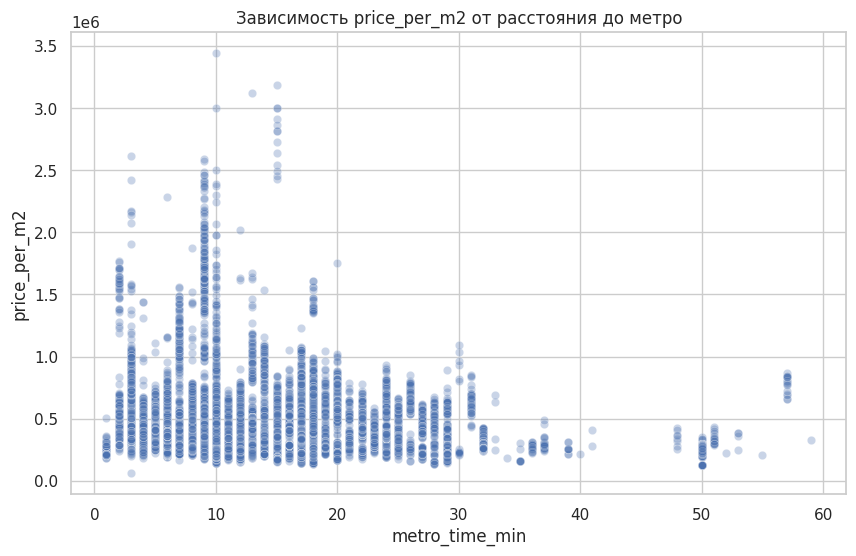

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x="metro_time_min", y = "price_per_m2", alpha=0.3)
plt.title("Зависимость price_per_m2 от расстояния до метро")
plt.show()

### **Общая площадь**

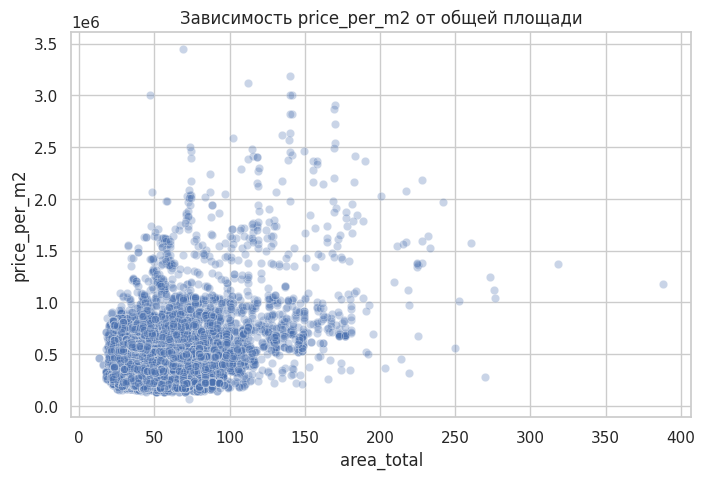

In [56]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="area_total", y="price_per_m2", alpha=0.3)
plt.title("Зависимость price_per_m2 от общей площади")
plt.show()

### **Год постройки**

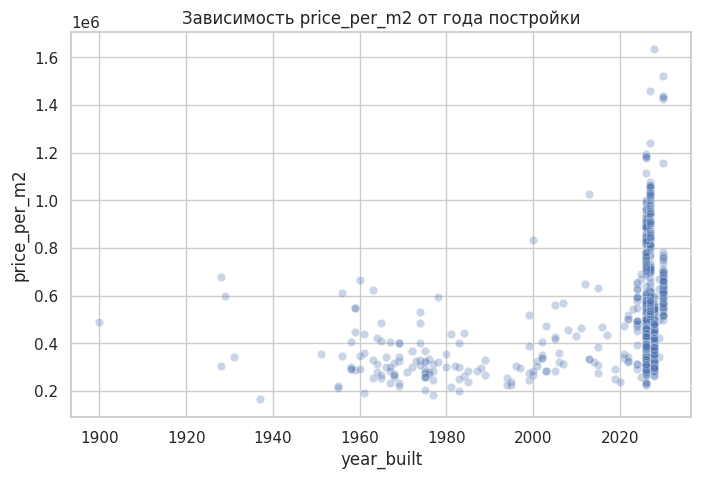

In [57]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="year_built", y="price_per_m2", alpha=0.3)
plt.title("Зависимость price_per_m2 от года постройки")
plt.show()

### **Вывод по связи таргета с числовыми признаками:**

- `metro_time_min`:
  - наблюдается отрицательная зависимость
  - чем дальше от метро, тем ниже цена за м²
  - один из ключевых факторов цены

- `area_total`:
  - слабая/умеренная зависимость
  - цена за м² не растет линейно с площадью
  - для больших квартир часто наблюдается снижение цены за м²

- `year_built`:
  - современные дома (после 2000+) имеют более высокую цену
  - новые здания (2020+) часто находятся в верхнем ценовом диапазоне

Общие наблюдения:
- зависимости нелинейные
- присутствует большой разброс значений
- есть выбросы (элитная недвижимость)


Расстояние до метро и год постройки — важные факторы цены, площадь влияет сложнее (нелинейно), для моделирования подходят алгоритмы, умеющие работать с нелинейностями (например, CatBoost)

# **Выбросы**

In [58]:
data.sort_values("price_per_m2", ascending=False)[
    ["price", "price_per_m2", "area_total", "district", "metro", "title"]
].head(20)

,price,price_per_m2,area_total,district,metro,title
7711,237667000.0,3444449.28,69.00,Замоскворечье,Новокузнецкая,"1-комнатную квартиру от застройщика, 69 м²"
6133,447561456.0,3188895.30,140.35,Замоскворечье,Новокузнецкая,"3-комнатная квартира от застройщика, 140.35 м²"
25,349689519.0,3122227.85,112.00,Хамовники,Киевская,"3-комнатная квартира, 112 м²"
6134,421651912.0,3004288.65,140.35,Замоскворечье,Новокузнецкая,"3-комнатную квартиру от застройщика, 140.35 м²"
6080,425377230.0,3004288.65,141.59,Замоскворечье,Новокузнецкая,"3-комнатную квартиру от застройщика, 141.59 м²"
7705,141700000.0,3002118.64,47.20,Замоскворечье,Новокузнецкая,"1-комнатной квартиры от застройщика, 47.2 м²"
6110,494666493.0,2910316.49,169.97,Замоскворечье,Новокузнецкая,"4-комнатная квартира от застройщика, 169.97 м²"
6139,485436479.0,2864777.10,169.45,Замоскворечье,Новокузнецкая,"4-комнатную квартиру от застройщика, 169.45 м²"
6137,395742369.0,2819682.00,140.35,Замоскворечье,Новокузнецкая,"3-комнатную квартиру от застройщика, 140.35 м²"
6079,399238774.0,2819682.00,141.59,Замоскворечье,Новокузнецкая,"3-комнатной квартиры от застройщика, 141.59 м²"


In [60]:
data.sort_values("price_per_m2", ascending=True)[
    ["price", "price_per_m2", "area_total", "district", "metro", "title"]
].head(20)

,price,price_per_m2,area_total,district,metro,title
57,4550000.0,62328.77,73.00,Ясенево,Ясенево,"3-комнатная квартира, 73 м²"
9876,6760000.0,130000.00,52.00,Северное Медведково,Медведково,"2-комнатную квартиру от застройщика, 52 м²"
9879,9152000.0,130000.00,70.40,Северное Медведково,Медведково,"2-комнатной квартиры от застройщика, 70.4 м²"
9880,9152000.0,130000.00,70.40,Северное Медведково,Медведково,"2-комнатная квартира от застройщика, 70.4 м²"
9895,7371000.0,130000.00,56.70,Северное Медведково,Медведково,"2-комнатной квартиры от застройщика, 56.7 м²"
9892,6643000.0,130000.00,51.10,Северное Медведково,Медведково,"2-комнатную квартиру от застройщика, 51.1 м²"
9891,6643000.0,130000.00,51.10,Северное Медведково,Медведково,"2-комнатную квартиру от застройщика, 51.1 м²"
9893,6643000.0,130000.00,51.10,Северное Медведково,Медведково,"2-комнатную квартиру от застройщика, 51.1 м²"
9899,9152000.0,130000.00,70.40,Северное Медведково,Медведково,"2-комнатную квартиру от застройщика, 70.4 м²"
9897,8047000.0,130000.00,61.90,Северное Медведково,Медведково,"2-комнатную квартиру от застройщика, 61.9 м²"


In [10]:
q1 = data["price_per_m2"].quantile(0.01)
q99 = data["price_per_m2"].quantile(0.99)

data_filtered = data[
    (data["price_per_m2"] >= q1) & 
    (data["price_per_m2"] <= q99)
]

print("До фильтрации:", data.shape)
print("После фильтрации:", data_filtered.shape)

print("Удалено объектов", data.shape[0] - data_filtered.shape[0])

До фильтрации: (14534, 31)
После фильтрации: (14244, 31)


### **Вывод по выбросам:**

- В данных присутствуют экстремальные значения `price_per_m2`:
  - очень дорогие объекты (элитная недвижимость)
  - а также аномально дешевые объявления
- По примерам видно, что часть выбросов — реальные объекты (новостройки премиум-класса), а не ошибки данных

По фильтрации:
- при отсечении по 1–99 перцентилю удаляется небольшая доля объектов (~2%)
- это не критично для объема данных

Решение:
- в baseline модели выбросы НЕ удаляются
- так как CatBoost устойчив к выбросам
- при необходимости можно использовать фильтрацию или логарифмирование таргета


Выбросы присутствуют, но отражают реальный рынок, модель должна учитывать такие объекты, а не игнорировать их полностью

# **Итоги EDA:**

- Данные представляют реальный рынок недвижимости: присутствуют выбросы, асимметрия и разброс цен  
- Таргет `price_per_m2` имеет скошенное распределение и выбросы, но подходит для моделирования  
- Ключевые факторы цены:
  - локация (`district`, `metro`, `okrug`)
  - площадь (`area_total`, `area_living`)
  - расстояние до метро (`metro_time_min`)
  - характеристики дома (`year_built`, этажность)

- В данных есть пропуски, но они могут быть обработаны (заполнение / игнорирование)  
- Обнаружена мультиколлинеарность между признаками площади, что не критично для CatBoost  
- Выбросы являются частью реальных данных (элитная недвижимость) и не удаляются в baseline  


Итог:

Данные подготовлены для обучения модели, выбран подход с использованием CatBoost, устойчивого к выбросам и категориальным признакам, можно переходить к построению и улучшению модели